# Landslide Risk Prediction Gradient Boosting

This notebook walks through the complete landslide classification workflow:

- data loading and inspection
- preprocessing and feature scaling
- train/test split
- model training with Gradient Boosting
- model evaluation and a simple prediction example

The code is intentionally annotated so each step is easy to follow and reuse. Feel free to use my code for your purpose.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8')
%matplotlib inline

## Data Collection and Exploratory Inspection

In this section, we load the dataset, inspect its structure, and review the target distribution before training the model.

In [21]:
# Load the processed dataset from the project data folder.
# The header row contains the feature names and target label.
landslide_data = pd.read_csv('../data/raw/landslide_dataset.csv', header=0)

In [23]:
# Preview the first few rows to understand the column structure and sample values.
landslide_data.head()

,Rainfall_mm,Slope_Angle,Soil_Saturation,Vegetation_Cover,Earthquake_Activity,Proximity_to_Water,Landslide,Soil_Type_Gravel,Soil_Type_Sand,Soil_Type_Silt
0,206.181018,58.275001,0.892798,0.339463,4.390047,0.099975,1,0,0,0
1,218.887334,36.679801,0.657147,0.360355,4.141029,0.832443,1,0,0,1
2,181.850867,31.363874,0.673362,0.221697,5.311891,0.023062,1,0,0,1
3,228.716199,38.995134,0.618666,0.489502,4.581928,0.785176,1,0,0,1
4,179.951067,42.998205,0.836966,0.118580,5.518862,0.450499,1,0,0,0


In [24]:
# Check the total number of rows and columns in the dataset.
landslide_data.shape

(2000, 10)

In [25]:
# Generate summary statistics for the numeric columns.
# This helps identify ranges, spread, and any unusual values.
landslide_data.describe()

,Rainfall_mm,Slope_Angle,Soil_Saturation,Vegetation_Cover,Earthquake_Activity,Proximity_to_Water,Landslide,Soil_Type_Gravel,Soil_Type_Sand,Soil_Type_Silt
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.0000,2000.00000
mean,176.688462,29.985404,0.540316,0.522862,3.604771,1.001867,0.500000,0.25850,0.2415,0.26100
std,65.724685,15.175902,0.295665,0.260426,1.895955,0.579964,0.500125,0.43792,0.4281,0.43929
min,50.036151,5.003944,0.000652,0.100005,0.001641,0.000653,0.000000,0.00000,0.0000,0.00000
25%,128.379762,18.018061,0.265634,0.295475,1.973415,0.500808,0.000000,0.00000,0.0000,0.00000
50%,177.013772,27.772833,0.599887,0.500191,3.996429,0.999761,0.500000,0.00000,0.0000,0.00000
75%,228.742286,41.683190,0.801994,0.740690,5.233897,1.505294,1.000000,1.00000,0.0000,1.00000
max,299.919102,59.966732,0.998831,0.999837,6.498670,1.999636,1.000000,1.00000,1.0000,1.00000


In [26]:
# Count how many samples belong to each class in the target variable.
# A balanced or clearly understood target distribution helps us interpret model performance later.
landslide_data['Landslide'].value_counts()

Landslide
1    1000
0    1000
Name: count, dtype: int64

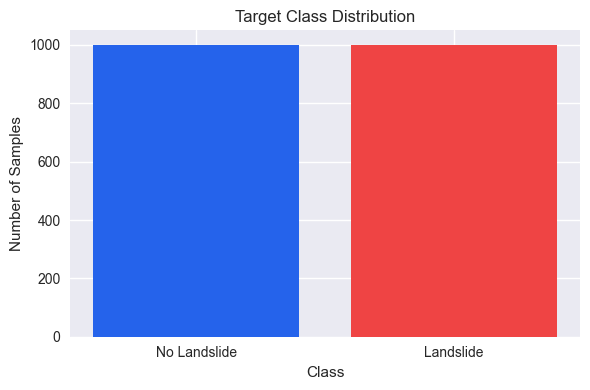

In [27]:
# Visualize the class distribution to make the target imbalance easier to understand.
class_counts = landslide_data['Landslide'].value_counts().sort_index()
class_labels = ['No Landslide', 'Landslide']

plt.figure(figsize=(6, 4))
plt.bar(class_labels, class_counts.values, color=['#2563eb', '#ef4444'])
plt.title('Target Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.show()

1 -> Landslide  
0 -> No landslide

In [28]:
# Compare average feature values for the two classes.
# This gives a quick sense of which variables may differ between landslide and non-landslide cases.
landslide_data.groupby('Landslide').mean()

,Rainfall_mm,Slope_Angle,Soil_Saturation,Vegetation_Cover,Earthquake_Activity,Proximity_to_Water,Soil_Type_Gravel,Soil_Type_Sand,Soil_Type_Silt
Landslide,,,,,,,,,
0,127.111331,17.717390,0.282473,0.748140,1.974215,1.502907,0.517,0.483,0.000
1,226.265592,42.253418,0.798160,0.297583,5.235326,0.500827,0.000,0.000,0.522


In [29]:
# Separate the feature matrix (X) from the target label (Y).
# 'Landslide' is the prediction target, so it should not remain inside X.
X = landslide_data.drop(columns=['Landslide'])
Y = landslide_data['Landslide']

In [30]:
# Count how many samples belong to each class in the target variable.
# A balanced or clearly understood target distribution helps us interpret model performance later.
landslide_data['Landslide'].value_counts()

Landslide
1    1000
0    1000
Name: count, dtype: int64

In [31]:
print(X)

      Rainfall_mm  Slope_Angle  Soil_Saturation  Vegetation_Cover  \
0      206.181018    58.275001         0.892798          0.339463   
1      218.887334    36.679801         0.657147          0.360355   
2      181.850867    31.363874         0.673362          0.221697   
3      228.716199    38.995134         0.618666          0.489502   
4      179.951067    42.998205         0.836966          0.118580   
...           ...          ...              ...               ...   
1995   195.650778    27.084662         0.567332          0.556801   
1996   197.339684    22.715510         0.037470          0.517580   
1997    75.759674     6.631750         0.266207          0.925309   
1998    50.919297    16.603380         0.014794          0.954346   
1999   188.083126    28.372795         0.093188          0.516938   

      Earthquake_Activity  Proximity_to_Water  Soil_Type_Gravel  \
0                4.390047            0.099975                 0   
1                4.141029            

In [32]:
print(Y)

0       1
1       1
2       1
3       1
4       1
       ..
1995    0
1996    0
1997    0
1998    0
1999    0
Name: Landslide, Length: 2000, dtype: int64


### Splitting Data Into Training and Testing Sets

In [33]:
# Split the dataset into training and testing portions.
# stratify=Y keeps class proportions similar in both sets.
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, stratify=Y, random_state=2
)

print(X.shape, X_train.shape, X_test.shape)

(2000, 9) (1600, 9) (400, 9)


### Feature Scaling (For Workflow Consistency)

In [34]:
# Gradient Boosting does not require scaling as strongly as linear models,
# but we keep this step to maintain a consistent preprocessing pipeline.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Building and Training the Gradient Boosting Model

In [35]:
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=2
)

gb_model.fit(X_train_scaled, Y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

### Model Evaluation Using Accuracy Score

In [36]:
# Evaluate performance on training data.
X_train_prediction = gb_model.predict(X_train_scaled)
training_data_accuracy = accuracy_score(Y_train, X_train_prediction)

print('Accuracy score of the training data : ', training_data_accuracy)

Accuracy score of the training data :  1.0


In [37]:
# Evaluate performance on test data.
X_test_prediction = gb_model.predict(X_test_scaled)
test_data_accuracy = accuracy_score(Y_test, X_test_prediction)

print('Accuracy score of the test data : ', test_data_accuracy)

Accuracy score of the test data :  1.0


### Making a Predictive System

In [ ]:
# Example input with all feature columns used during training.
# Replace values below with real sensor/environment measurements for actual use.
input_data = pd.DataFrame([
    {
        'Rainfall_mm': 210.0,
        'Slope_Angle': 35.0,
        'Soil_Saturation': 0.82,
        'Vegetation_Cover': 0.25,
        'Earthquake_Activity': 4.8,
        'Proximity_to_Water': 0.45,
        'Soil_Type_Gravel': 0,
        'Soil_Type_Sand': 1,
        'Soil_Type_Silt': 0,
    }
])

# Reorder columns defensively so input matches training feature order.
input_data = input_data[X.columns]
input_data_scaled = scaler.transform(input_data)
prediction = gb_model.predict(input_data_scaled)

print('Predicted Class:', prediction[0])
if prediction[0] == 1:
    print('The area is at risk of a landslide.')
else:
    print('The area is not at risk of a landslide.')

Predicted Class: 1
The area is at risk of a landslide.
